<div style="text-align:center;">
    <h1 style="color:red; font-size:24px;"></h1>
</div>

AIM : To develop a model for predicting the demand for shared bikes and identify significant variables, you can follow a systematic approach using statistical and machine learning techniques. Here are the steps you can take:

 - Data Collection and Preprocessing:

Gather relevant data related to shared bike usage, such as weather conditions, time of day, day of the week, holidays, promotional events, etc.
Clean the data by handling missing values, outliers, and any inconsistencies.
 - Exploratory Data Analysis (EDA):

Conduct EDA to understand the distribution of the variables, correlations between variables, and identify any patterns or trends in the data.
Visualize the data using plots like histograms, scatter plots, and correlation matrices.
 - Feature Selection:

Use techniques like correlation analysis, feature importance from machine learning models (e.g., random forests), and domain knowledge to select relevant features.
Consider factors like seasonality, weather impact, promotional activities, and economic indicators that might influence bike demand.
 - Model Building:

Choose an appropriate regression model such as linear regression, decision tree regression, or ensemble methods like random forest or gradient boosting.
Split the data into training and testing sets for model evaluation.
Train the model using the training data and evaluate its performance using metrics like R-squared, mean absolute error (MAE), and root mean squared error (RMSE).
 - Interpretation and Validation:

Interpret the coefficients or feature importances from the model to understand the significance of each variable in predicting bike demand.
Validate the model using the testing data to ensure its generalization and predictive power.
 - Business Insights:

Once you have a validated model, use it to make predictions on future bike demand based on input variables.
Provide actionable insights to the management on which variables significantly impact bike demand and how they can manipulate these factors to meet customer expectations and optimize business strategies.
Consider scenarios like adjusting pricing strategies, promoting bike usage during favorable weather conditions, or launching targeted marketing campaigns during peak demand periods.

By following these steps, you can develop a robust model to predict bike demand and extract valuable insights for strategic decision-making in your shared bike business.

# STEP 1 -  Understanding data

####  - IMPORT LIBRARIES

In [1]:
# for analysis and numerical calculations

import pandas as pd
import numpy as np


# for data visualization

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# for warnings

import warnings
warnings.filterwarnings("ignore")


#### - LOADING AND READING DATA 

In [3]:
df = pd.read_csv("day (1).csv")

In [4]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [5]:
# checking shape

df.shape

(730, 16)

There are 16 columns and 730 rows in the data.

In [6]:
# checking columns and its data types

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


Data looks fine, all columns are either integer or float

Only one column 'dteday' seems to be of object datatype

In [7]:
# statistical summary

df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [8]:
# checking for missing in our dataset

df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

There seems to be no missing or null values in our dataset.

####  - ANOMALY CHECK

In [9]:
# checking for all columns 

df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

 - The column 'instant' seems to be an index for our dataset
 - dteday has date, the same can be extracted from month and year columns, analysis can be performed on these columns
 - casual + registered = cnt , hence no need of these two columns as well.
   
All the above stated columns are not useful for further analysis hence dropping these columns
   

In [10]:
# dropping unwanted and unnecessary cols

df = df.drop(['instant', 'dteday' ,'casual', 'registered'] , axis =1)

In [11]:
df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

SEGREGATING NUMERICAL AND CATEGORICAL DATA 

In [12]:
num_cols = ["temp","atemp","hum","windspeed","cnt"]
cat_cols = ["season","yr","mnth","holiday","weekday","workingday","weathersit"]

#### - ANALYZE DATA AS PER SEGREGATION

  - Analysis on categorical variables

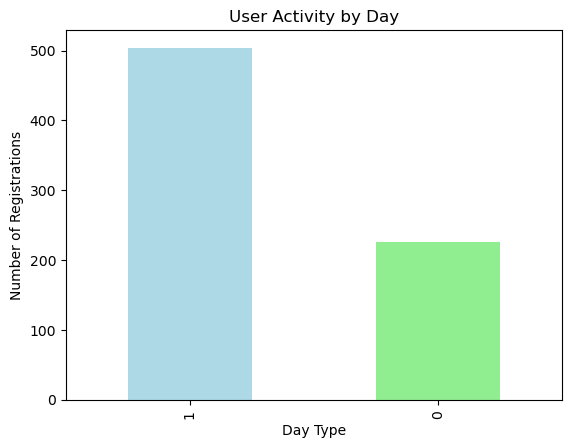

In [13]:
df['workingday'].value_counts().plot(kind='bar', color=['lightblue', 'lightgreen'])

# Add labels and title
plt.xlabel('Day Type')
plt.ylabel('Number of Registrations')
plt.title('User Activity by Day')

# Show plot
plt.show()

More users sign up on weekdays, likely because they are working during those days.

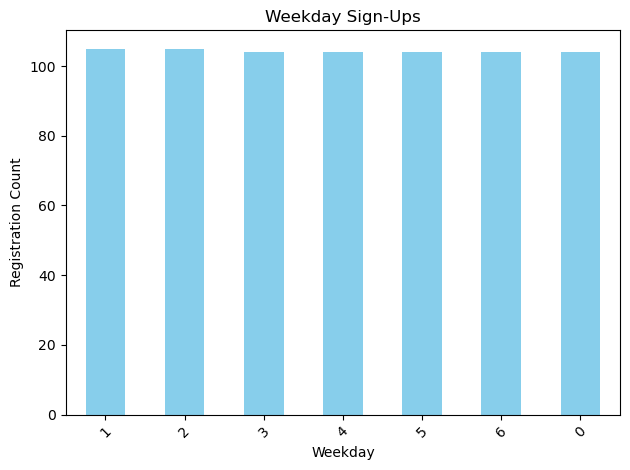

In [14]:
ax = df['weekday'].value_counts().plot(kind='bar', color='skyblue', xlabel='Weekday', ylabel='Registration Count', title='Weekday Sign-Ups')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()

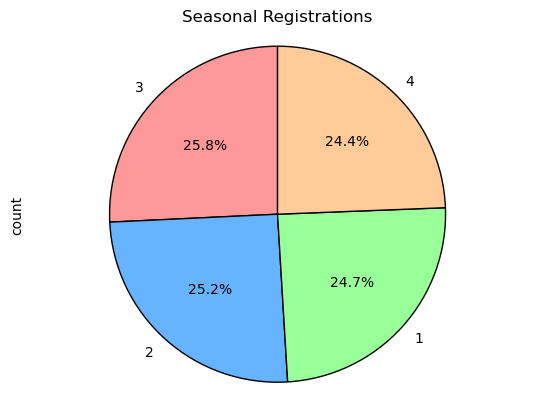

In [15]:
df['season'].value_counts().plot.pie(autopct='%.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'], wedgeprops={'edgecolor': 'black'})

# Add title
plt.title("Seasonal Registrations")

# Show plot
plt.axis('equal')
plt.show()

Registrations are almost the same for each season, showing consistent interest throughout the year.

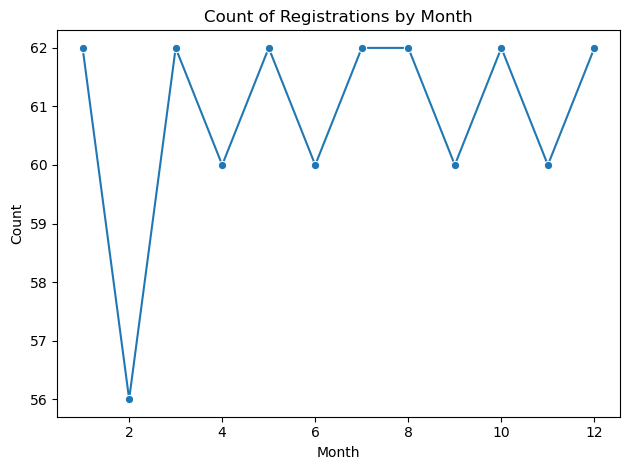

In [16]:
sns.lineplot(data=df['mnth'].value_counts().sort_index(), marker='o')

# Set labels and title
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Count of Registrations by Month')

# Show plot
plt.tight_layout()
plt.show()

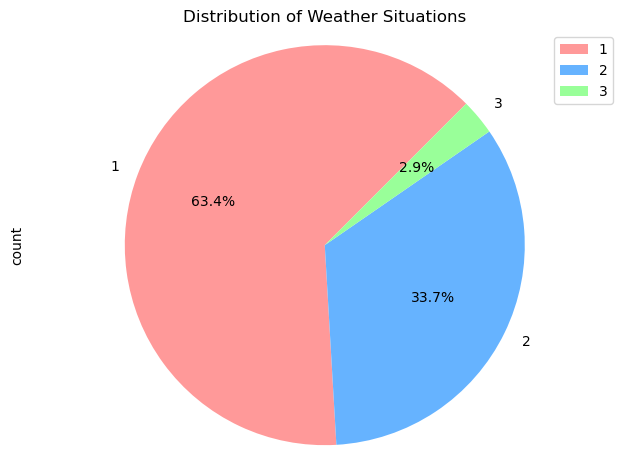

In [17]:
df['weathersit'].value_counts().plot.pie(autopct='%.1f%%', startangle=45, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']); plt.title('Distribution of Weather Situations'); plt.legend(labels=df['weathersit'].value_counts().index, loc='best'); plt.axis('equal'); plt.tight_layout(); plt.show()


The pie chart illustrates that weather situation 1 (63.42%) is predominant, followed by situation 2 (33.70%) and situation 3 (2.88%)

  - Analysis on numerical variables

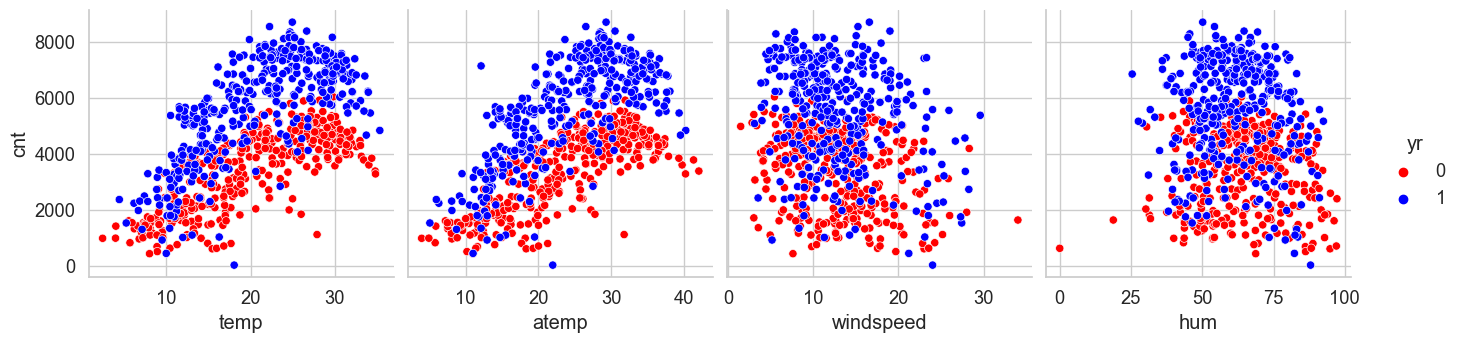

In [18]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create the pairplot with custom style and context
sns.pairplot(df, x_vars=["temp", 'atemp', 'windspeed', "hum"], y_vars=['cnt'], hue='yr', palette=['red', 'blue'], height=3.5)

# Show the plot
plt.show()

##  - DATA VISUALIZATION

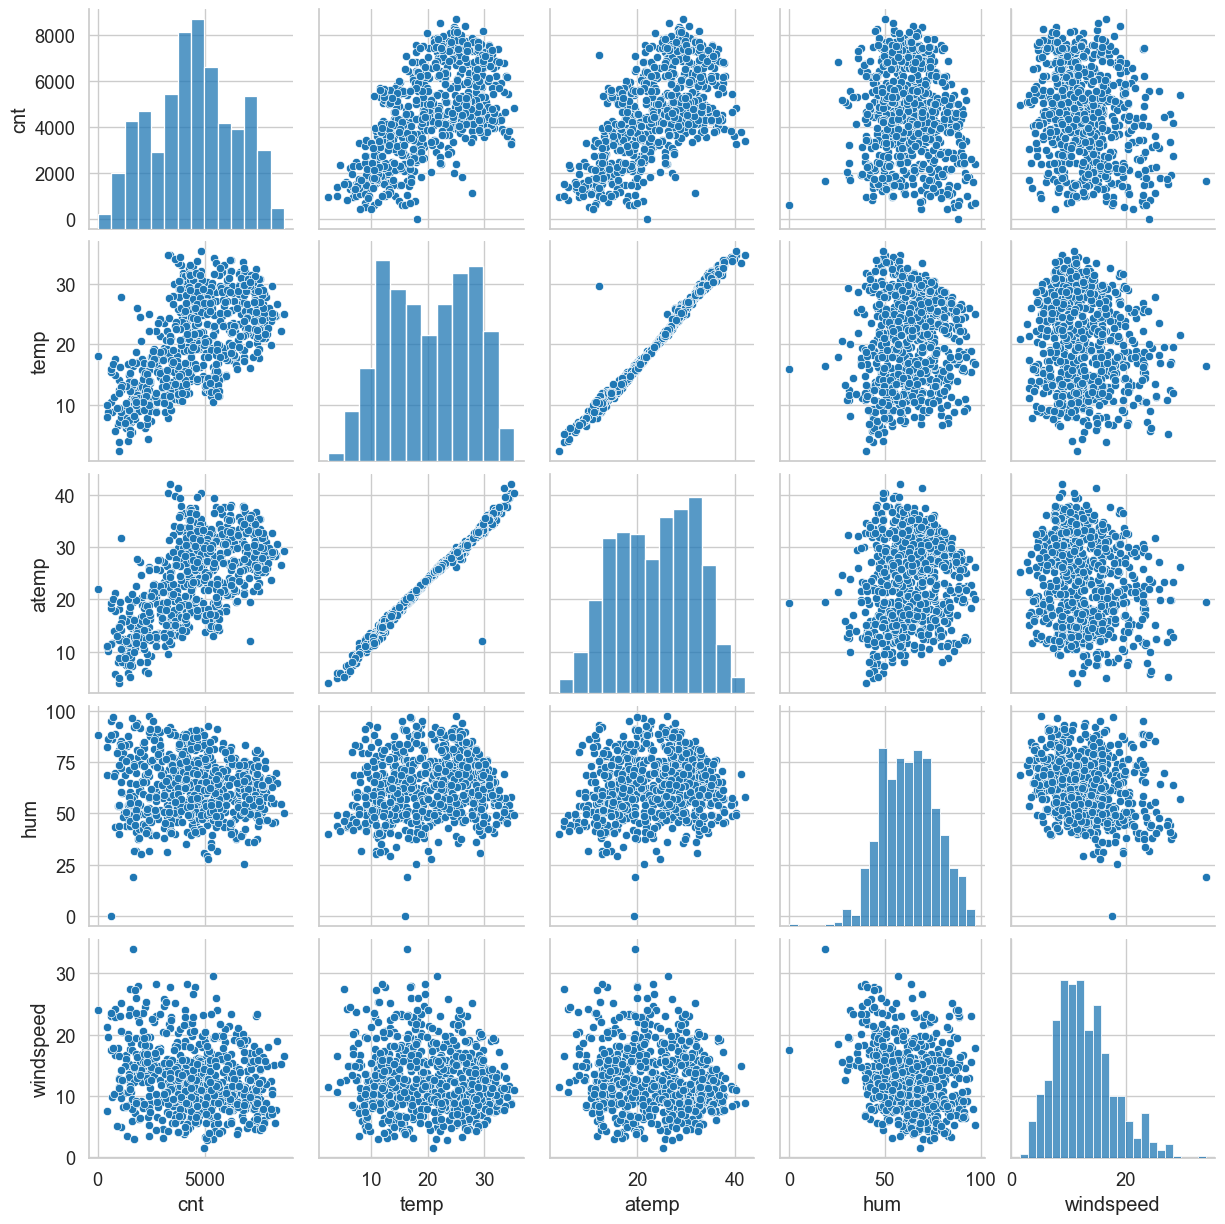

In [19]:
sns.pairplot(df, vars=["cnt","temp","atemp","hum","windspeed"])
plt.show()

1. Humidity and windspeed do not show a direct linear relationship with bike usage (cnt).
2. Bike usage (cnt) has a notably positive correlation with both temperature (temp) and perceived temperature (atemp), indicating their impact on usage levels.
3. The nearly straight line in the scatter plot suggests a strong and consistent relationship between temperature, perceived temperature, and bike usage, highlighting their predictive power for usage patters. 
.


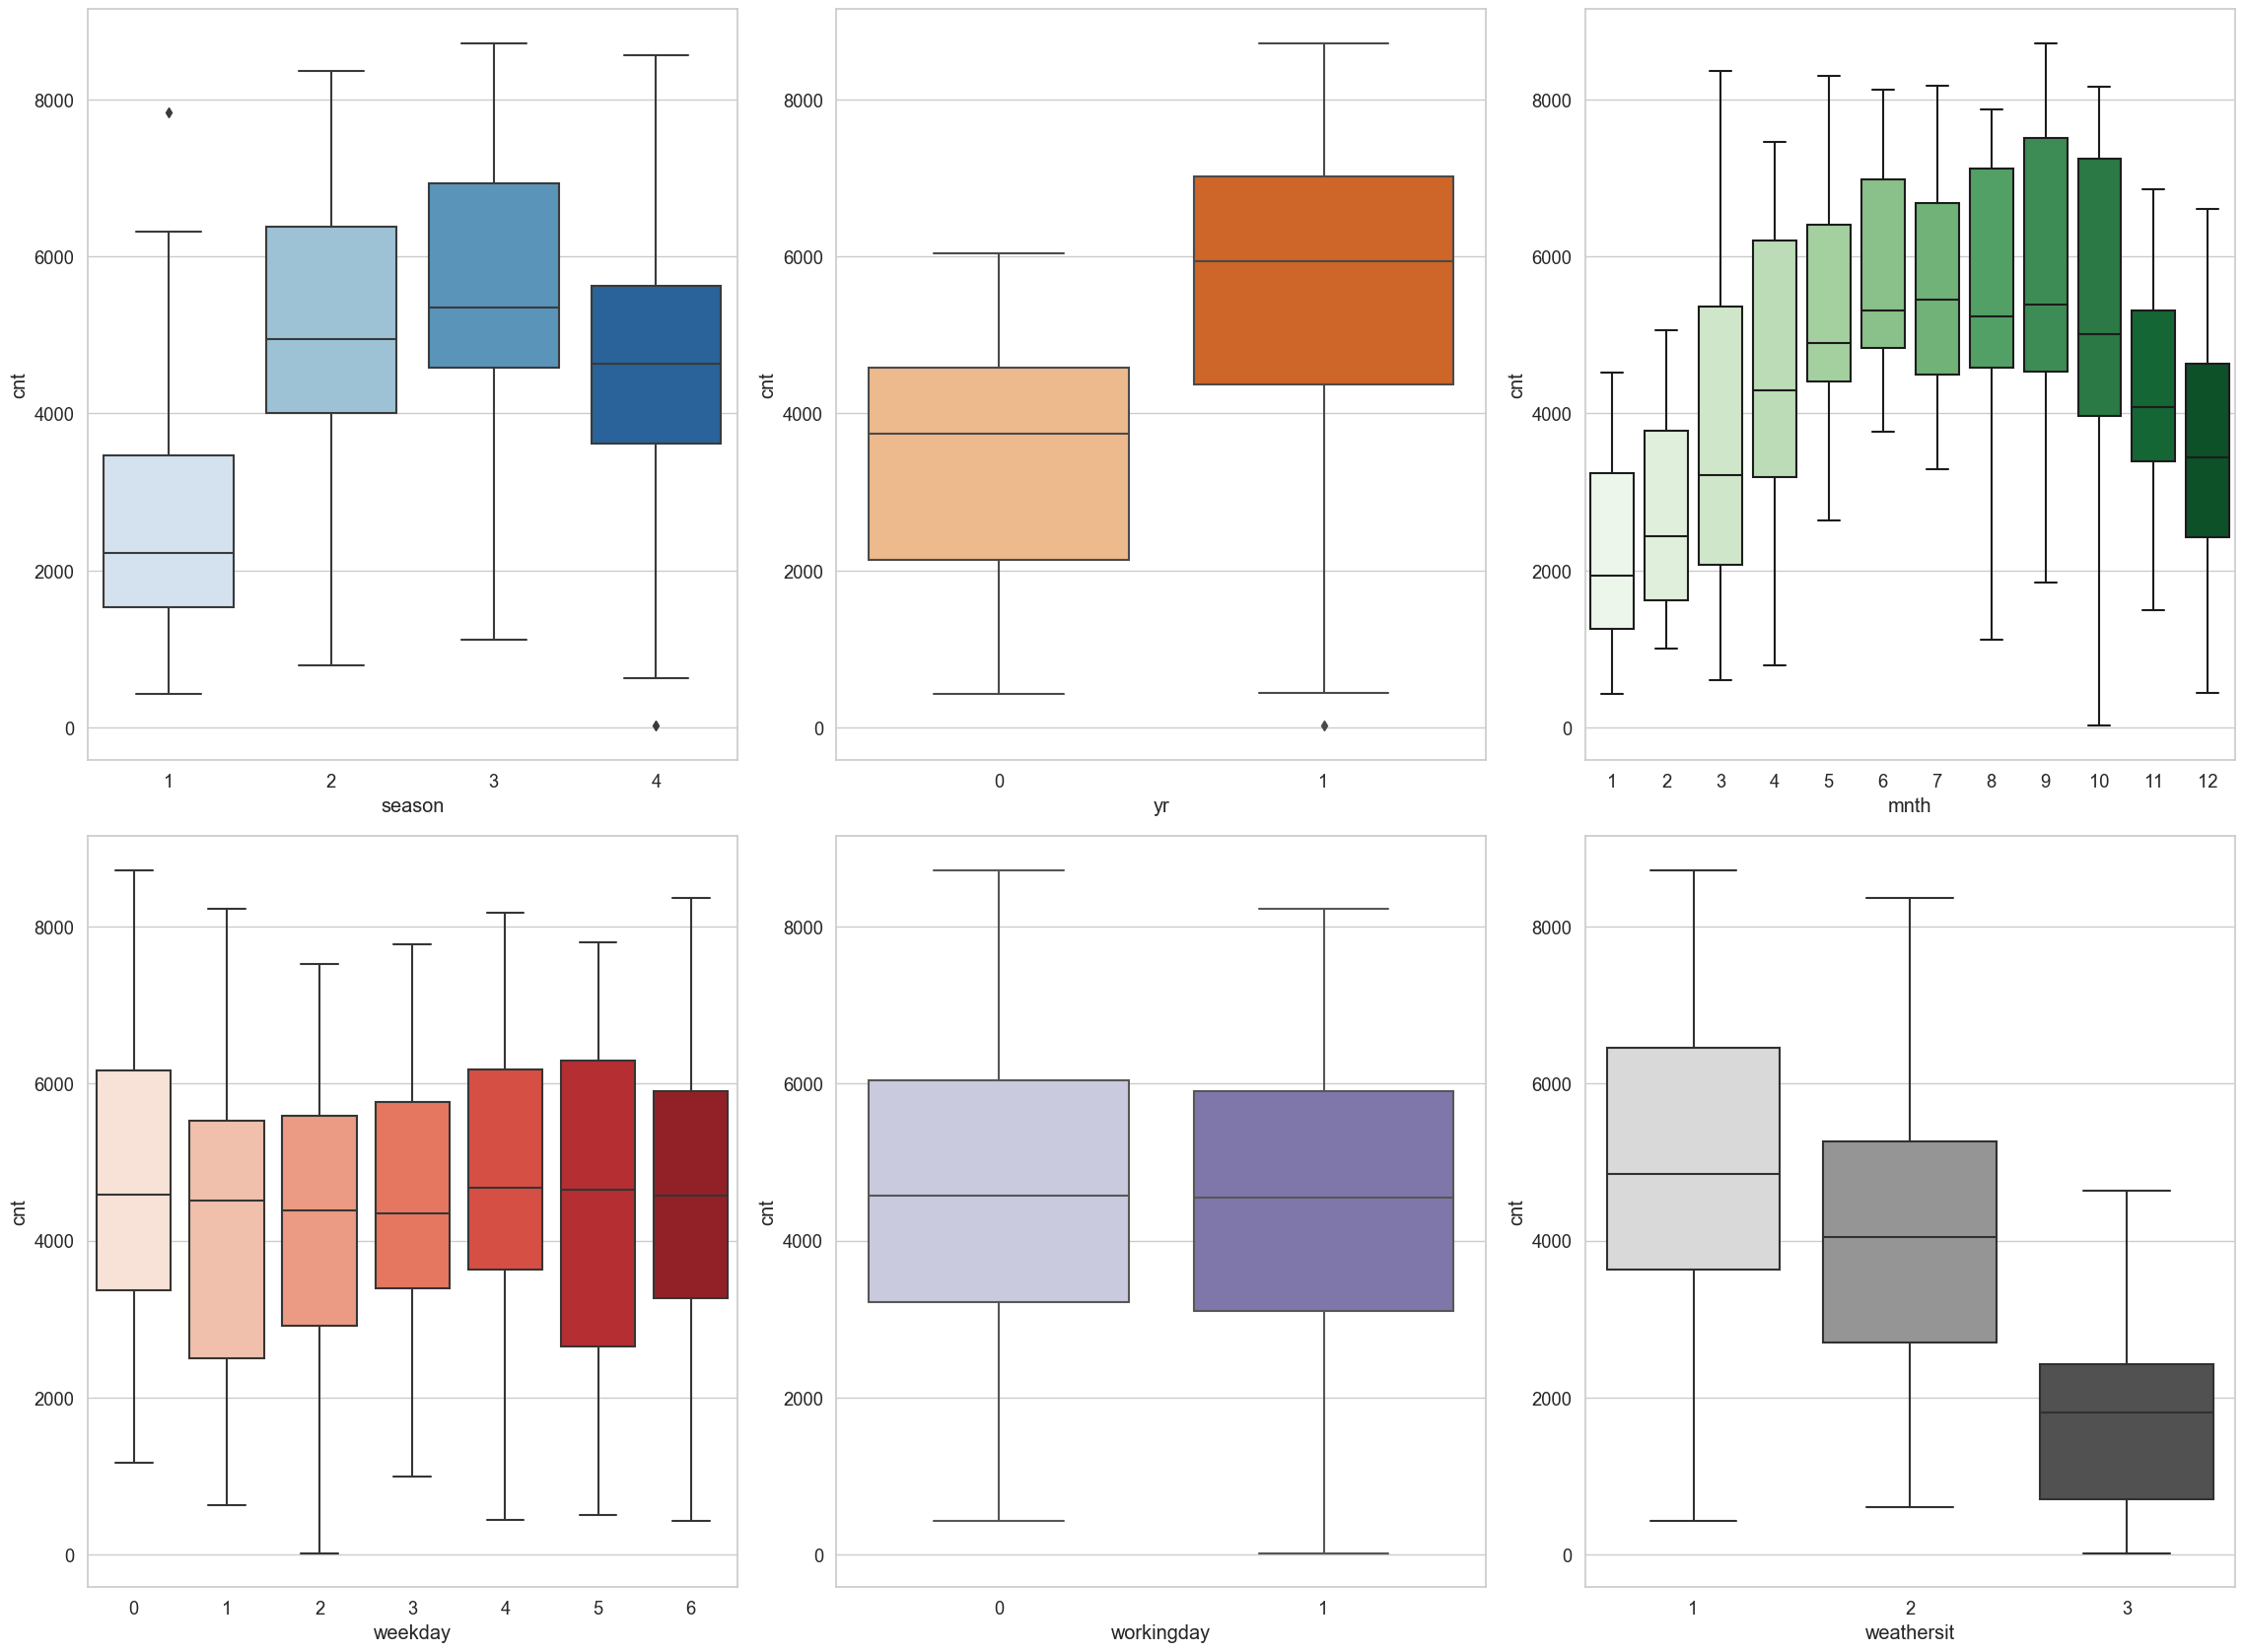

In [20]:

plt.figure(figsize=(23,17))

sns.boxplot(x='season', y='cnt', data=df, palette='Blues', ax=plt.subplot(2,3,1))
sns.boxplot(x='yr', y='cnt', data=df, palette='Oranges', ax=plt.subplot(2,3,2))
sns.boxplot(x='mnth', y='cnt', data=df, palette='Greens', ax=plt.subplot(2,3,3))
sns.boxplot(x='weekday', y='cnt', data=df, palette='Reds', ax=plt.subplot(2,3,4))
sns.boxplot(x='workingday', y='cnt', data=df, palette='Purples', ax=plt.subplot(2,3,5))
sns.boxplot(x='weathersit', y='cnt', data=df, palette='Greys', ax=plt.subplot(2,3,6))

plt.tight_layout()
plt.show()

## CORRELATION MATRIX 

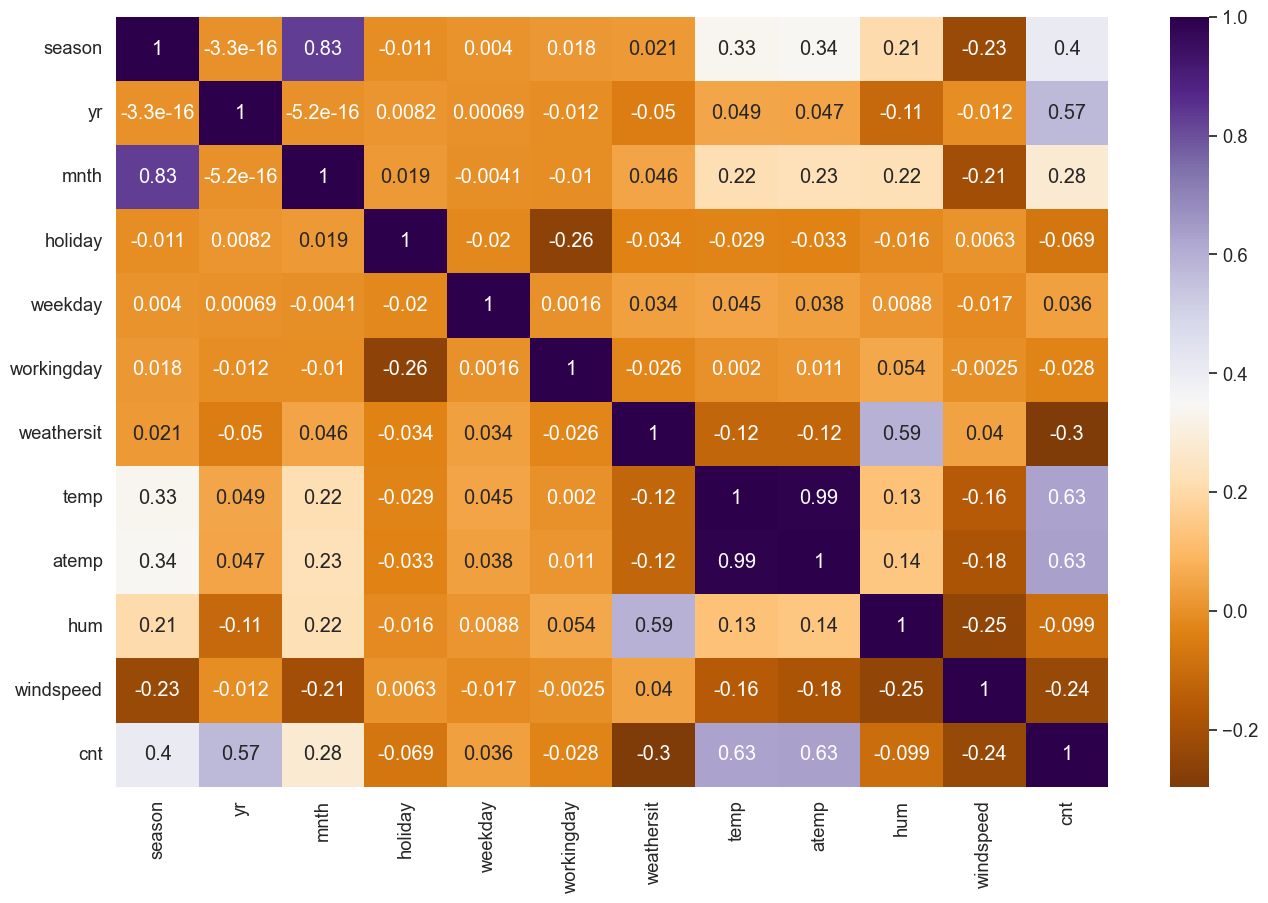

In [21]:

plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), annot = True, cmap="PuOr")
plt.show()


1. Variables like temp, atemp, yr, season, and mnth demonstrate strong correlations with the target variable count.

2. Temp and atemp exhibit a perfect correlation, indicating they essentially represent the same information.

3. Hum and weathersit show a high correlation, suggesting a relationship between humidity and weather conditions.

4. Season has high correlations with temp, atemp, and hum, indicating seasonal variations in these variables.

In [22]:
# dropping temp columns for further analysis, and avoid multicollinearity

df = df.drop(['temp'] ,axis = 1 )

## STEP 2 -  Data Preparation

In [23]:
df.nunique()

season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
atemp         689
hum           594
windspeed     649
cnt           695
dtype: int64

 -- Converting all binary categorical data's values and updating descriptive name's for more clear understanding

1. Updating values of 'season' variable

In [24]:
df['season'] = df['season'].map({1: 'Spring' , 2: 'Summer' , 3: 'Fall' , 4: 'Winter'})

In [25]:
# checking for its values as categorical variables

df.season.unique()

array(['Spring', 'Summer', 'Fall', 'Winter'], dtype=object)

In [26]:
df.season.value_counts()

season
Fall      188
Summer    184
Spring    180
Winter    178
Name: count, dtype: int64

2. Updating values of 'mnth' variable

In [27]:
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

# Use the replace method to map values
df['mnth'] = df['mnth'].replace(month_names)


In [28]:
df.mnth.unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [29]:
df.mnth.value_counts()

mnth
January      62
March        62
May          62
July         62
August       62
October      62
December     62
April        60
June         60
September    60
November     60
February     56
Name: count, dtype: int64

3. Updating values of 'weekday' variable

In [30]:
df['weekday'] = df['weekday'].map({0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'})

In [31]:
df.weekday.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object)

In [32]:
df.weekday.value_counts()

weekday
Monday       105
Tuesday      105
Wednesday    104
Thursday     104
Friday       104
Saturday     104
Sunday       104
Name: count, dtype: int64

4. Updating values of 'weathersit' variable

In [33]:
df['weathersit'] = df['weathersit'].map({1: 'Clear', 2: 'Cloudy', 3: 'Rainy'})

In [34]:
# df.weathersit.unique()

In [35]:
df.weathersit.value_counts()

weathersit
Clear     463
Cloudy    246
Rainy      21
Name: count, dtype: int64

## STEP 3 -  Data Preprocessing

We need to change categorical variables to numbers for regression.

Let's turn them into 0s and 1s for analysis.







--- For variables with 2 categories, use 0s and 1s; for more than two categories, create dummy variables.

In [36]:
df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [37]:
df.nunique()

season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
atemp         689
hum           594
windspeed     649
cnt           695
dtype: int64

As we can see there appears to three columns with only two categories lets convert them to 0 and 1's

In [38]:
df.yr.unique()  # its already in its binary format, we can proceed this as it is

array([0, 1], dtype=int64)

In [39]:
df.holiday.unique() #already in its binary format, we can proceed this as it is

array([0, 1], dtype=int64)

In [40]:
df.workingday.unique() #already in its binary format, we can proceed this as it is

array([1, 0], dtype=int64)

We can proceed as is since categorical variables with only two categories already have binary encoding (0s and 1s).

We will now proceed with variables having more than 2 categories and will process them accordingly

#### columns with more than 2 categorical values : season , mnth , weekday and weathersit

In [41]:
df.season.unique()
# preprocessing req, as it has more than 2 unique values

array(['Spring', 'Summer', 'Fall', 'Winter'], dtype=object)

In [42]:
dum1 = pd.get_dummies(df.season , drop_first= True , dtype=int)   #dummies  = n-1

In [43]:
dum1.head()

,Spring,Summer,Winter
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [44]:
df.mnth.unique()
# preprocessing req, as it has more than 2 unique values

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [45]:
dum2 = pd.get_dummies(df.mnth , drop_first= True , dtype=int)   #dummies  = n-1

In [46]:
dum2.tail()

,August,December,February,January,July,June,March,May,November,October,September
725,0,1,0,0,0,0,0,0,0,0,0
726,0,1,0,0,0,0,0,0,0,0,0
727,0,1,0,0,0,0,0,0,0,0,0
728,0,1,0,0,0,0,0,0,0,0,0
729,0,1,0,0,0,0,0,0,0,0,0


In [47]:
df.weekday.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object)

In [48]:
dum3 = pd.get_dummies(df.weekday , drop_first= True , dtype=int)   #dummies  = n-1

In [49]:
dum3.tail()

,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
725,0,0,0,0,0,0
726,0,1,0,0,0,0
727,0,0,1,0,0,0
728,1,0,0,0,0,0
729,0,0,0,0,1,0


In [50]:
df.weathersit.unique()

array(['Cloudy', 'Clear', 'Rainy'], dtype=object)

In [51]:
dum4 = pd.get_dummies(df.weathersit , drop_first= True , dtype=int)   #dummies  = n-1

In [52]:
dum4.tail()

,Cloudy,Rainy
725,1,0
726,1,0
727,1,0
728,0,0
729,1,0


In [53]:
# Concatenate new dataframes dum1, dum2 , dum3 , dum4  with old df and drop other existing columns dummies derived from.

In [54]:
df = pd.concat([df , dum1 , dum2 , dum3  , dum4] , axis  = 1)

In [55]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,...,October,September,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,Cloudy,Rainy
0,Spring,0,January,0,Monday,1,Cloudy,18.18125,80.5833,10.749882,...,0,0,1,0,0,0,0,0,1,0
1,Spring,0,January,0,Tuesday,1,Cloudy,17.68695,69.6087,16.652113,...,0,0,0,0,0,0,1,0,1,0
2,Spring,0,January,0,Wednesday,1,Clear,9.47025,43.7273,16.636703,...,0,0,0,0,0,0,0,1,0,0
3,Spring,0,January,0,Thursday,1,Clear,10.60610,59.0435,10.739832,...,0,0,0,0,0,1,0,0,0,0
4,Spring,0,January,0,Friday,1,Clear,11.46350,43.6957,12.522300,...,0,0,0,0,0,0,0,0,0,0


In [56]:
df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed', 'cnt', 'Spring', 'Summer',
       'Winter', 'August', 'December', 'February', 'January', 'July', 'June',
       'March', 'May', 'November', 'October', 'September', 'Monday',
       'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday', 'Cloudy',
       'Rainy'],
      dtype='object')

In [57]:
df = df.drop(['season' ,'mnth' , 'weekday' , 'weathersit' ], axis = 1)

In [58]:
df.head()

,yr,holiday,workingday,atemp,hum,windspeed,cnt,Spring,Summer,Winter,...,October,September,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,Cloudy,Rainy
0,0,0,1,18.18125,80.5833,10.749882,985,1,0,0,...,0,0,1,0,0,0,0,0,1,0
1,0,0,1,17.68695,69.6087,16.652113,801,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2,0,0,1,9.47025,43.7273,16.636703,1349,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,1,10.60610,59.0435,10.739832,1562,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,11.46350,43.6957,12.522300,1600,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   yr          730 non-null    int64  
 1   holiday     730 non-null    int64  
 2   workingday  730 non-null    int64  
 3   atemp       730 non-null    float64
 4   hum         730 non-null    float64
 5   windspeed   730 non-null    float64
 6   cnt         730 non-null    int64  
 7   Spring      730 non-null    int32  
 8   Summer      730 non-null    int32  
 9   Winter      730 non-null    int32  
 10  August      730 non-null    int32  
 11  December    730 non-null    int32  
 12  February    730 non-null    int32  
 13  January     730 non-null    int32  
 14  July        730 non-null    int32  
 15  June        730 non-null    int32  
 16  March       730 non-null    int32  
 17  May         730 non-null    int32  
 18  November    730 non-null    int32  
 19  October     730 non-null    i

In [60]:
df.shape

(730, 29)

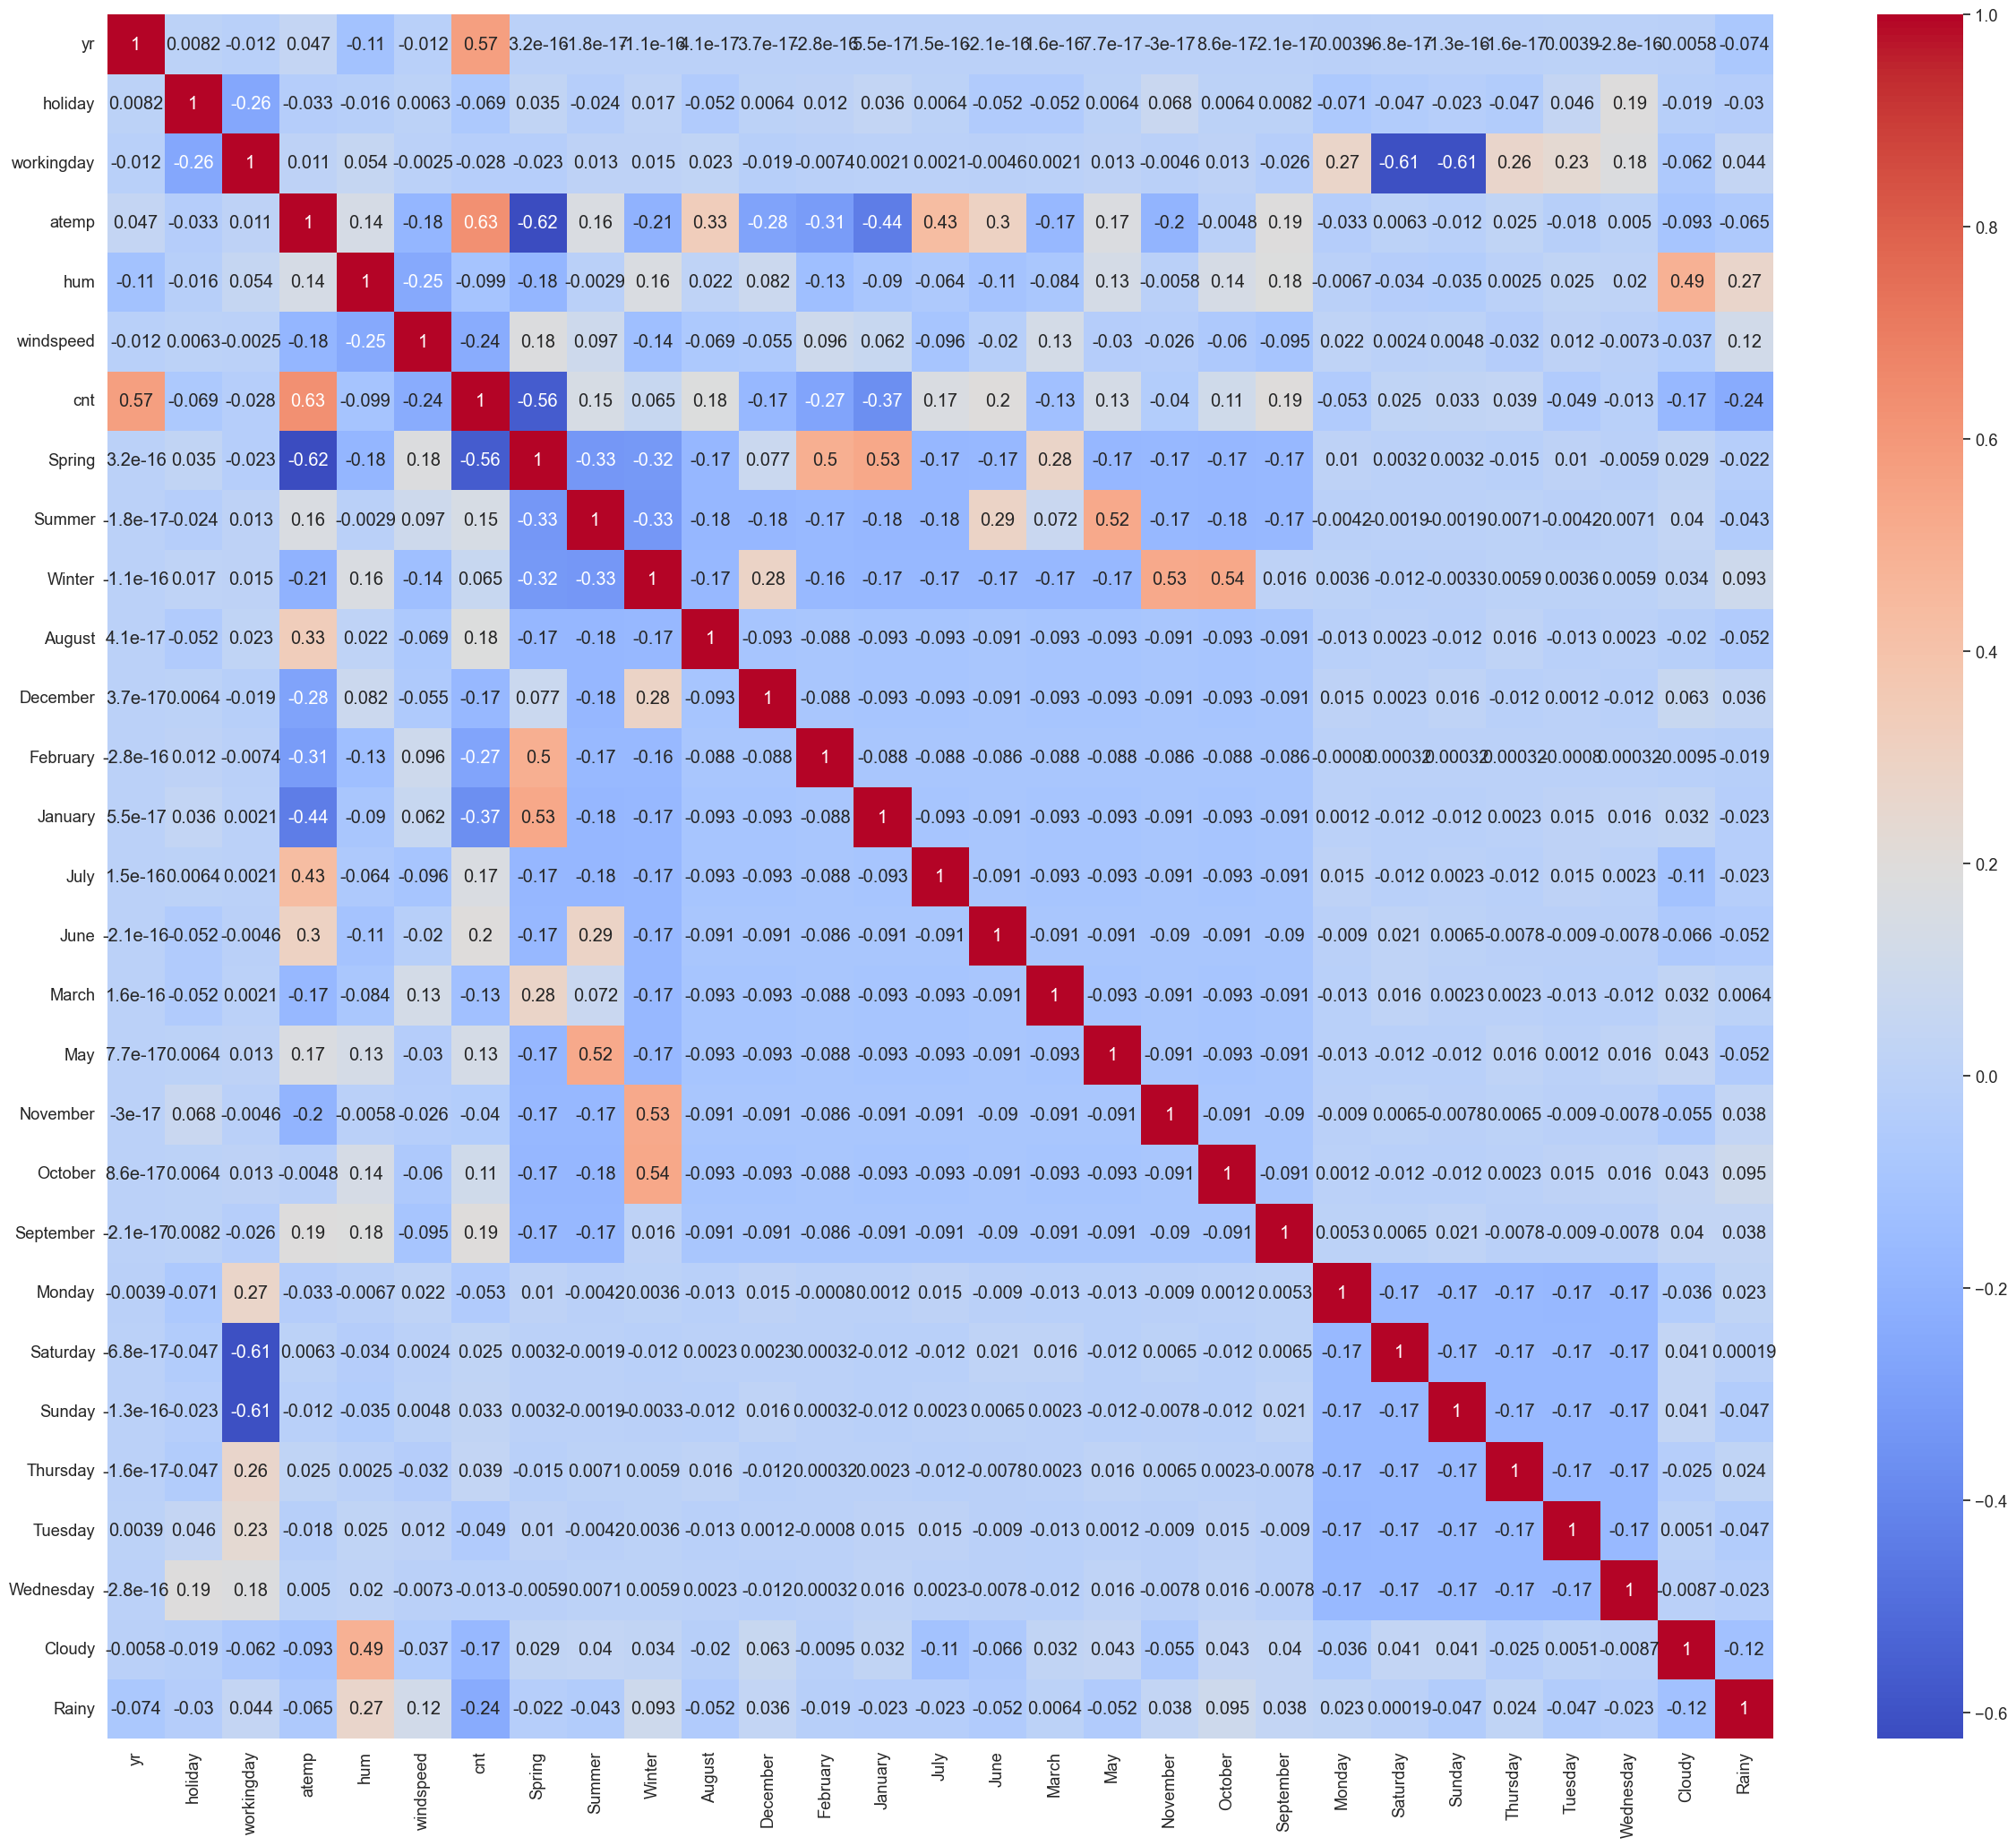

In [61]:
plt.figure(figsize = (30, 25))
sns.heatmap(df.corr(), annot = True, cmap="coolwarm")
plt.show()

In the end, we are left with 28 columns, all of which are either float or integer.

## STEP 4 - Training the data

####  -  TRAIN_TEST_SPLIT

In [62]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively

df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 100)

In [63]:
df_train.shape

(510, 29)

In [64]:
df_test.shape

(219, 29)

####  - MIN_MAX_SCALING

In [65]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [66]:
# Apply scaler() to all the columns except the 'yes-no' and 'dummy' variables
num_vars = ['atemp','hum','windspeed','cnt']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

df_train.head()

,yr,holiday,workingday,atemp,hum,windspeed,cnt,Spring,Summer,Winter,...,October,September,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,Cloudy,Rainy
653,1,0,1,0.501133,0.575354,0.300794,0.864243,0,0,1,...,1,0,0,0,0,0,0,1,0,0
576,1,0,1,0.766351,0.725633,0.264686,0.827658,0,0,0,...,0,0,0,0,0,0,0,1,0,0
426,1,0,0,0.438975,0.640189,0.255342,0.465255,1,0,0,...,0,0,0,0,1,0,0,0,1,0
728,1,0,1,0.200348,0.498067,0.663106,0.204096,1,0,0,...,0,0,1,0,0,0,0,0,0,0
482,1,0,0,0.391735,0.504508,0.188475,0.482973,0,1,0,...,0,0,0,0,1,0,0,0,1,0


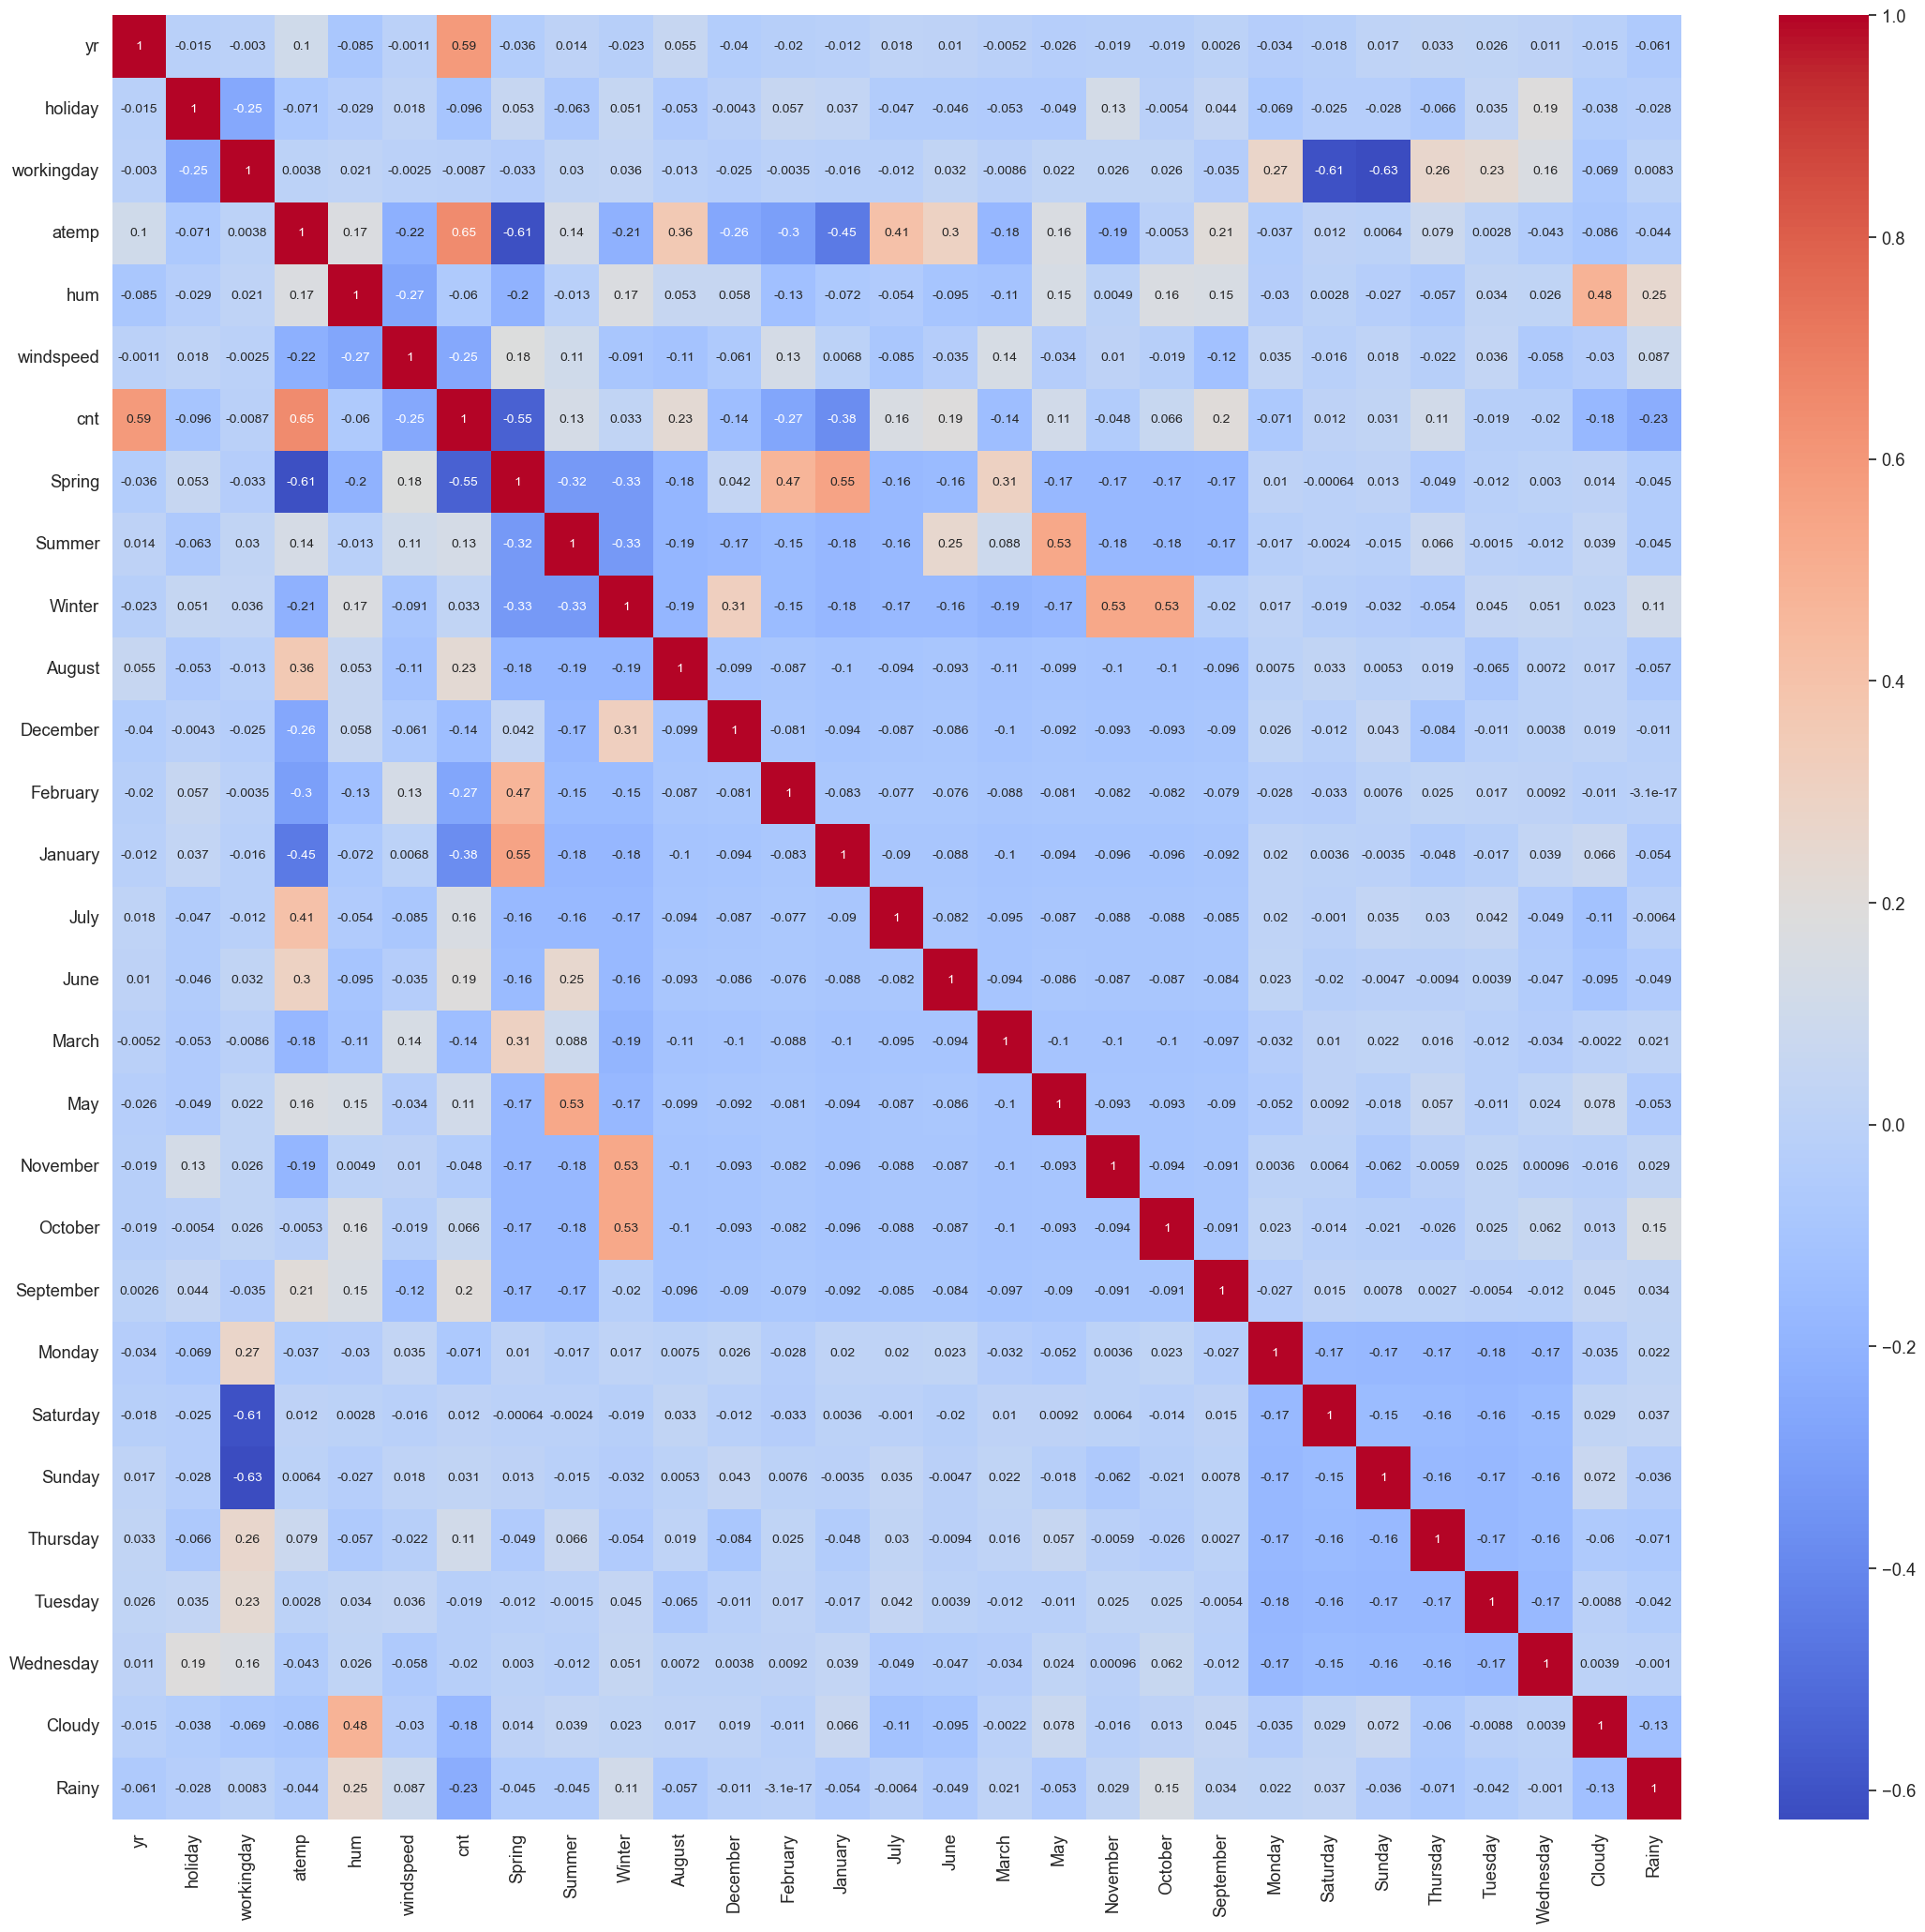

In [67]:
plt.figure(figsize = (27,25))
sns.heatmap(df_train.corr(), annot = True, cmap="coolwarm",annot_kws={"fontsize":10})
plt.show()


### Splitting the model creation into X and Y sets


In [68]:
y_train = df_train.pop('cnt')
X_train = df_train

####  - BUILDING MODEL
This time, we will be using the **LinearRegression function from SciKit Learn** for its compatibility with RFE (which is a utility from sklearn)

In [69]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [70]:
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm,n_features_to_select= 15)             # running RFE
rfe = rfe.fit(X_train, y_train)

In [71]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 2),
 ('atemp', True, 1),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('Spring', False, 5),
 ('Summer', True, 1),
 ('Winter', True, 1),
 ('August', True, 1),
 ('December', True, 1),
 ('February', True, 1),
 ('January', True, 1),
 ('July', False, 10),
 ('June', False, 7),
 ('March', False, 14),
 ('May', False, 6),
 ('November', True, 1),
 ('October', False, 12),
 ('September', True, 1),
 ('Monday', False, 9),
 ('Saturday', False, 3),
 ('Sunday', False, 4),
 ('Thursday', False, 13),
 ('Tuesday', False, 8),
 ('Wednesday', False, 11),
 ('Cloudy', True, 1),
 ('Rainy', True, 1)]

In [72]:
col = X_train.columns[rfe.support_]
col

Index(['yr', 'holiday', 'atemp', 'hum', 'windspeed', 'Summer', 'Winter',
       'August', 'December', 'February', 'January', 'November', 'September',
       'Cloudy', 'Rainy'],
      dtype='object')

In [73]:
X_train.columns[~rfe.support_]

Index(['workingday', 'Spring', 'July', 'June', 'March', 'May', 'October',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='object')


### -   Creating a model for the detailed statistics using statsmodel


In [74]:
X_train_rfe = X_train[col]

In [75]:
import statsmodels.api as sm  
X_train_rfe = sm.add_constant(X_train_rfe)

In [76]:
model1 = sm.OLS(y_train,X_train_rfe).fit()   # Running the linear model

####  - MODEL1

In [77]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     175.1
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.26e-186
Time:                        19:34:52   Log-Likelihood:                 508.57
No. Observations:                 510   AIC:                            -985.1
Df Residuals:                     494   BIC:                            -917.4
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2936      0.032      9.289      0.000       0.232       0.356
yr             0.2311      0.008     28.328      0.000       0.215       0.247
holiday       -0.0838      0.026     -3.233      0.001      -0.135      -0.033
atemp          0.4765      0.032     14.938      0.000       0.414       0.539
hum           -0.1627      0.038     -4.277      0.000      -0.237      -0.088
windspeed     -0.1769      0.026     -6.784      0.000      -0.228      -0.126
Summer         0.0779      0.013      6.180      0.000       0.053       0.103
Winter         0.1358      0.014      9.541      0.000       0.108       0.164
August         0.0606      0.016      3.696      0.000       0.028       0.093
December      -0.0505      0.018     -2.732      0.007      -0.087      -0.014
February      -0.0504      0.021     -2.384      0.017      -0.092      -0.009
January       -0.0769      0.021     -3.617      0.000      -0.119      -0.035
November      -0.0440      0.019     -2.316      0.021      -0.081      -0.007
September      0.1116      0.017      6.688      0.000       0.079       0.144
Cloudy        -0.0569      0.011     -5.377      0.000      -0.078      -0.036
Rainy         -0.2420      0.027     -9.070      0.000      -0.294      -0.190
==============================================================================
Omnibus:                       67.622   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              171.611
Skew:                          -0.675   Prob(JB):                     5.43e-38
Kurtosis:                       5.501   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [78]:
# X_train_sm = X_train_sm.drop("November" , axis = 1)
# X_test_sm = X_test_sm.drop("November" , axis = 1)

In [79]:
X_train_rfe = X_train_rfe.drop(["November"], axis = 1)

In [80]:
X_train_rfe = sm.add_constant(X_train_rfe)

In [81]:
model2 = sm.OLS(y_train,X_train_rfe).fit() 

#### - MODEL2

In [82]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     185.6
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.29e-186
Time:                        19:34:52   Log-Likelihood:                 505.81
No. Observations:                 510   AIC:                            -981.6
Df Residuals:                     495   BIC:                            -918.1
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2791      0.031      8.969      0.000       0.218       0.340
yr             0.2311      0.008     28.197      0.000       0.215       0.247
holiday       -0.0911      0.026     -3.525      0.000      -0.142      -0.040
atemp          0.4946      0.031     15.923      0.000       0.434       0.556
hum           -0.1629      0.038     -4.264      0.000      -0.238      -0.088
windspeed     -0.1763      0.026     -6.729      0.000      -0.228      -0.125
Summer         0.0819      0.013      6.528      0.000       0.057       0.107
Winter         0.1224      0.013      9.372      0.000       0.097       0.148
August         0.0613      0.016      3.725      0.000       0.029       0.094
December      -0.0328      0.017     -1.940      0.053      -0.066       0.000
February      -0.0409      0.021     -1.964      0.050      -0.082    1.64e-05
January       -0.0662      0.021     -3.174      0.002      -0.107      -0.025
September      0.1169      0.017      7.047      0.000       0.084       0.150
Cloudy        -0.0562      0.011     -5.291      0.000      -0.077      -0.035
Rainy         -0.2377      0.027     -8.889      0.000      -0.290      -0.185
==============================================================================
Omnibus:                       61.152   Durbin-Watson:                   2.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.561
Skew:                          -0.619   Prob(JB):                     1.23e-33
Kurtosis:                       5.366   Cond. No.                         18.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [83]:
X_train_rfe = X_train_rfe.drop(["December"], axis = 1)

In [84]:
X_train_rfe = sm.add_constant(X_train_rfe)

####  - MODEL3

In [85]:
model3 = sm.OLS(y_train,X_train_rfe).fit() 
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     198.5
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          5.80e-187
Time:                        19:34:52   Log-Likelihood:                 503.88
No. Observations:                 510   AIC:                            -979.8
Df Residuals:                     496   BIC:                            -920.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2648      0.030      8.735      0.000       0.205       0.324
yr             0.2308      0.008     28.093      0.000       0.215       0.247
holiday       -0.0899      0.026     -3.469      0.001      -0.141      -0.039
atemp          0.5164      0.029     17.779      0.000       0.459       0.573
hum           -0.1711      0.038     -4.495      0.000      -0.246      -0.096
windspeed     -0.1718      0.026     -6.567      0.000      -0.223      -0.120
Summer         0.0873      0.012      7.116      0.000       0.063       0.111
Winter         0.1229      0.013      9.390      0.000       0.097       0.149
August         0.0635      0.016      3.854      0.000       0.031       0.096
February      -0.0301      0.020     -1.495      0.136      -0.070       0.009
January       -0.0531      0.020     -2.685      0.007      -0.092      -0.014
September      0.1209      0.017      7.324      0.000       0.088       0.153
Cloudy        -0.0550      0.011     -5.171      0.000      -0.076      -0.034
Rainy         -0.2325      0.027     -8.714      0.000      -0.285      -0.180
==============================================================================
Omnibus:                       56.552   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              139.652
Skew:                          -0.575   Prob(JB):                     4.73e-31
Kurtosis:                       5.292   Cond. No.                         18.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [86]:
X_train_rfe = X_train_rfe.drop(["February"], axis = 1)

In [87]:
X_train_rfe = sm.add_constant(X_train_rfe)

#### - MODEL4

In [88]:
model4 = sm.OLS(y_train,X_train_rfe).fit() 
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     214.3
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.18e-187
Time:                        19:34:52   Log-Likelihood:                 502.73
No. Observations:                 510   AIC:                            -979.5
Df Residuals:                     497   BIC:                            -924.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2496      0.029      8.727      0.000       0.193       0.306
yr             0.2303      0.008     28.021      0.000       0.214       0.246
holiday       -0.0917      0.026     -3.541      0.000      -0.143      -0.041
atemp          0.5347      0.026     20.288      0.000       0.483       0.587
hum           -0.1735      0.038     -4.554      0.000      -0.248      -0.099
windspeed     -0.1721      0.026     -6.568      0.000      -0.224      -0.121
Summer         0.0939      0.011      8.192      0.000       0.071       0.116
Winter         0.1317      0.012     11.261      0.000       0.109       0.155
August         0.0668      0.016      4.086      0.000       0.035       0.099
January       -0.0400      0.018     -2.253      0.025      -0.075      -0.005
September      0.1240      0.016      7.558      0.000       0.092       0.156
Cloudy        -0.0548      0.011     -5.148      0.000      -0.076      -0.034
Rainy         -0.2315      0.027     -8.669      0.000      -0.284      -0.179
==============================================================================
Omnibus:                       53.272   Durbin-Watson:                   2.039
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              133.306
Skew:                          -0.537   Prob(JB):                     1.13e-29
Kurtosis:                       5.263   Cond. No.                         18.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [89]:
X_train_rfe.columns

Index(['const', 'yr', 'holiday', 'atemp', 'hum', 'windspeed', 'Summer',
       'Winter', 'August', 'January', 'September', 'Cloudy', 'Rainy'],
      dtype='object')

In [90]:
X_train_rfe = X_train_rfe.drop(['const'], axis=1)

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

####  - VIF

In [92]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_rfe.columns

vif_data["VIF"] = [variance_inflation_factor(X_train_rfe.values , i)
                  for i in range(len(X_train_rfe.columns))]
vif_data

,Feature,VIF
0,yr,2.035742
1,holiday,1.041845
2,atemp,11.462056
3,hum,18.542553
4,windspeed,3.600933
5,Summer,1.955136
6,Winter,2.026519
7,August,1.561660
8,January,1.540505
9,September,1.314943


In [93]:
X_train_rfe = X_train_rfe.drop(['hum'], axis=1)

####  - VIF1 

In [94]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_rfe.columns

vif_data["VIF"] = [variance_inflation_factor(X_train_rfe.values , i)
                  for i in range(len(X_train_rfe.columns))]
vif_data

,Feature,VIF
0,yr,2.035063
1,holiday,1.038796
2,atemp,4.946231
3,windspeed,3.273392
4,Summer,1.899990
5,Winter,1.566395
6,August,1.561651
7,January,1.222164
8,September,1.309136
9,Cloudy,1.538336


VIF is less than 5 hence its valid and acceptable

In [95]:
# checking columns of the final model

X_train_rfe.columns

Index(['yr', 'holiday', 'atemp', 'windspeed', 'Summer', 'Winter', 'August',
       'January', 'September', 'Cloudy', 'Rainy'],
      dtype='object')

In [96]:
X_train_rfe = sm.add_constant(X_train_rfe)

####  - MODEL5

In [97]:
model5 = sm.OLS(y_train,X_train_rfe).fit()
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     223.1
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.91e-184
Time:                        19:34:52   Log-Likelihood:                 492.31
No. Observations:                 510   AIC:                            -960.6
Df Residuals:                     498   BIC:                            -909.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1550      0.020      7.734      0.000       0.116       0.194
yr             0.2343      0.008     28.119      0.000       0.218       0.251
holiday       -0.0931      0.026     -3.525      0.000      -0.145      -0.041
atemp          0.5069      0.026     19.390      0.000       0.456       0.558
windspeed     -0.1410      0.026     -5.468      0.000      -0.192      -0.090
Summer         0.0901      0.012      7.732      0.000       0.067       0.113
Winter         0.1206      0.012     10.339      0.000       0.098       0.144
August         0.0649      0.017      3.898      0.000       0.032       0.098
January       -0.0463      0.018     -2.565      0.011      -0.082      -0.011
September      0.1176      0.017      7.059      0.000       0.085       0.150
Cloudy        -0.0824      0.009     -9.242      0.000      -0.100      -0.065
Rainy         -0.2791      0.025    -11.138      0.000      -0.328      -0.230
==============================================================================
Omnibus:                       52.093   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              123.089
Skew:                          -0.544   Prob(JB):                     1.87e-27
Kurtosis:                       5.147   Cond. No.                         12.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [98]:
model5.predict(X_train_rfe)

653    0.721511
576    0.740418
426    0.493354
728    0.397340
482    0.568952
         ...   
526    0.733150
578    0.845679
53     0.250143
350    0.245551
79     0.307912
Length: 510, dtype: float64

In [99]:
y_train

653    0.864243
576    0.827658
426    0.465255
728    0.204096
482    0.482973
         ...   
526    0.764151
578    0.832835
53     0.218017
350    0.312586
79     0.236424
Name: cnt, Length: 510, dtype: float64

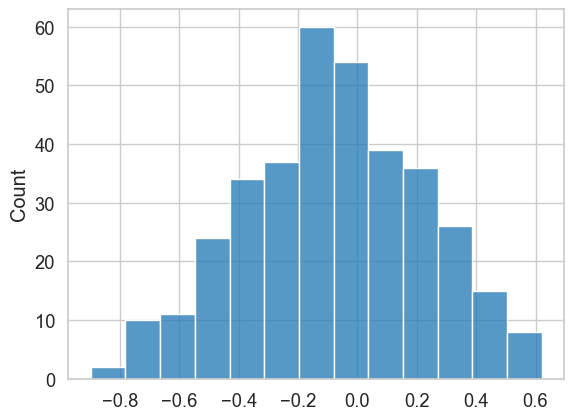

In [100]:
sns.histplot(model5.predict(X_train_rfe) - y_train.reset_index(drop = True))
plt.show()

## STEP 5  - Residual Analysis

### 1 . Confirming the assumptions for linear regression are satisfied.

In [101]:
y_train_pred = model5.predict(X_train_rfe)

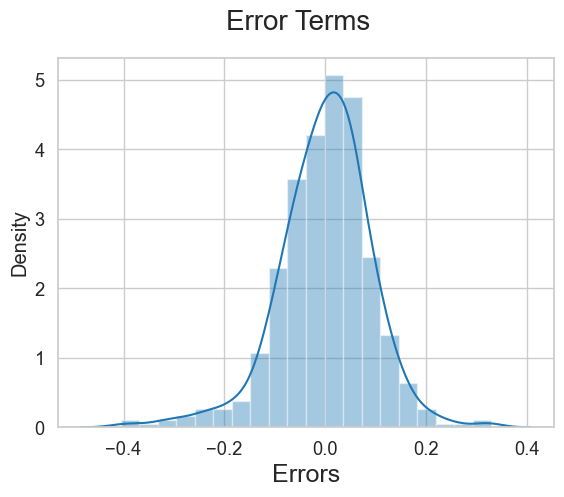

In [102]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)  
plt.show()

In [103]:
### 2. Serial correlation in errors

In [104]:
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     223.1
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.91e-184
Time:                        19:34:53   Log-Likelihood:                 492.31
No. Observations:                 510   AIC:                            -960.6
Df Residuals:                     498   BIC:                            -909.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1550      0.020      7.734      0.0


Target and feature variables have a linear relationship
.
The scatter plots show that temperature and cnt have a straight linear connection.



### 3. Heteroskedasticity.

Text(0, 0.5, 'error term')

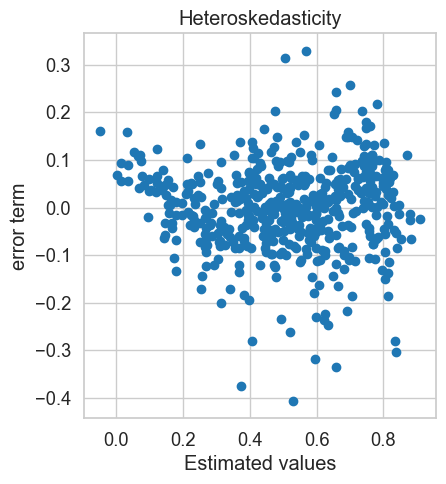

In [105]:
plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Heteroskedasticity")
plt.scatter(y_train_pred, (y_train-y_train_pred))
plt.xlabel("Estimated values")
plt.ylabel("error term")

Looking at the scatter plot, we don't see a widening or narrowing pattern as we move along the x-axis. Most points are close to zero and don't spread out or bunch up in a specific way. So, there's no heteroskedasticity..

### 4. Residuals must be normally distributed

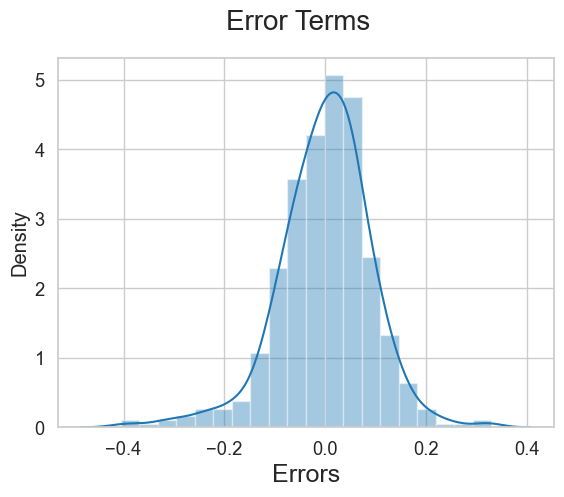

In [106]:
fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)  
plt.show()

Our residuals show a normal distribution, as illustrated in the distribution plot below. This means that the errors in our model follow a bell-shaped curve, which is a key assumption for many statistical analyses.

### 5. Multicollinearity

In [107]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_rfe.columns

vif_data["VIF"] = [variance_inflation_factor(X_train_rfe.values , i)
                  for i in range(len(X_train_rfe.columns))]
vif_data

,Feature,VIF
0,const,23.544113
1,yr,1.017835
2,holiday,1.016395
3,atemp,1.803729
4,windspeed,1.122527
5,Summer,1.473459
6,Winter,1.492388
7,August,1.412606
8,January,1.536825
9,September,1.204040


Since all the Variance Inflation Factors (VIFs) for our feature variables are below 5, we can confidently conclude that there is no multicollinearity present in our model. VIF values below 5 indicate that the predictor variables are not highly correlated with each other, which is an important condition for reliable regression analysis.

In [108]:

df_test[num_vars] = scaler.transform(df_test[num_vars])

In [109]:
y_test = df_test.pop('cnt')
X_test = df_test[:]

In [110]:
X_train_rfe.columns

Index(['const', 'yr', 'holiday', 'atemp', 'windspeed', 'Summer', 'Winter',
       'August', 'January', 'September', 'Cloudy', 'Rainy'],
      dtype='object')

In [111]:
X_train_rfe.drop(columns='const', inplace=True)

In [112]:
X_test_new = X_test[X_train_rfe.columns]

# Adding a constant variable 
X_test_new = sm.add_constant(X_test_new)

In [113]:
y_pred = model5.predict(X_test_new)

##  - STEP 6 :  Model Evaluation 

In [114]:
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     223.1
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.91e-184
Time:                        19:34:54   Log-Likelihood:                 492.31
No. Observations:                 510   AIC:                            -960.6
Df Residuals:                     498   BIC:                            -909.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1550      0.020      7.734      0.000       0.116       0.194
yr             0.2343      0.008     28.119      0.000       0.218       0.251
holiday       -0.0931      0.026     -3.525      0.000      -0.145      -0.041
atemp          0.5069      0.026     19.390      0.000       0.456       0.558
windspeed     -0.1410      0.026     -5.468      0.000      -0.192      -0.090
Summer         0.0901      0.012      7.732      0.000       0.067       0.113
Winter         0.1206      0.012     10.339      0.000       0.098       0.144
August         0.0649      0.017      3.898      0.000       0.032       0.098
January       -0.0463      0.018     -2.565      0.011      -0.082      -0.011
September      0.1176      0.017      7.059      0.000       0.085       0.150
Cloudy        -0.0824      0.009     -9.242      0.000      -0.100      -0.065
Rainy         -0.2791      0.025    -11.138      0.000      -0.328      -0.230
==============================================================================
Omnibus:                       52.093   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              123.089
Skew:                          -0.544   Prob(JB):                     1.87e-27
Kurtosis:                       5.147   Cond. No.                         12.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## The equation of the best-fitted line with the specified features and constant:

###   cnt =  0.1550 + (yr * 0.2343) - (holiday * 0.0931) + (atemp * 0.5069) - (windspeed * 0.1410) + (Summer * 0.0901) + (Winter * 0.1206) + (August * 0.649) - (January * 0.0463) + (September * 0.1176) - (Cloudy * 0.0824) - (Rainy * 0.2791))  

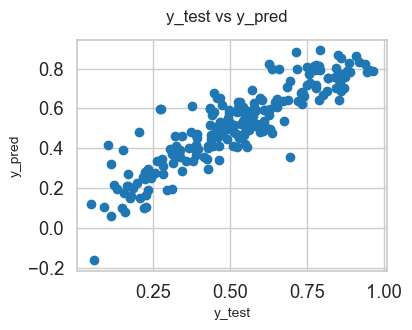

In [115]:
fig = plt.figure(figsize=(4, 3))  # Adjust the size as needed
plt.scatter(y_test, y_pred)
plt.suptitle('y_test vs y_pred', fontsize=12)  # Smaller title font size
plt.xlabel('y_test', fontsize=10)              # Smaller X-label font size
plt.ylabel('y_pred', fontsize=10)              # Smaller Y-label font size

# Show the plot
plt.show()

In [116]:
from sklearn.metrics import r2_score

In [117]:
print(r2_score(y_true=y_train, y_pred=y_train_pred))
print(r2_score(y_true=y_test, y_pred=y_pred))

0.8312944703924481
0.791027646986757


### We have a R-squared value of 83 % on train data and 79% on test data.